**How Are Inflation, Interest Rates, Unemployment, and Treasury Yields Related?**

Main question:

How are key economic indicators related, and how did those relationships change across different economic periods 
2000 to 2019 ?


In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt


**Loading Financial Data**

In [2]:
raw_data = pd.read_csv('./fredgraph_1999_2019.csv')

**Financial Data is from Fred**
What each ticker represent from Fred :

1. Unemployment Rate as UNRATE 
2. Consumer Price Index for All Urban Consumers as CPIAUCSL used to calculate inflation
3. Federal Funds Rate as FEDFUNDS
4. 10-Year Treasury Yield as DGS10


To achieve a perfectly row-aligned matrix, the daily series (DFF and DGS10) were converted to Monthly directly within the FRED interface before export 

Aggregation Method: The mathematical Average (Mean) was chosen to compress the daily rates into a single monthly value. Using the mean preserves the true economic cost of interest rates and bond yields for that specific month, keeping all variables in a uniform percentage format and preventing the data scale from breaking.


In [3]:
raw_data

,observation_date,UNRATE,CPIAUCSL,DGS10,DFF
0,1999-01-01,4.3,164.700,4.72,4.63
1,1999-02-01,4.4,164.700,5.00,4.76
2,1999-03-01,4.2,164.800,5.23,4.81
3,1999-04-01,4.3,165.900,5.18,4.74
4,1999-05-01,4.2,166.000,5.54,4.74
...,...,...,...,...,...
247,2019-08-01,3.6,256.036,1.63,2.13
248,2019-09-01,3.5,256.430,1.70,2.04
249,2019-10-01,3.6,257.155,1.71,1.83
250,2019-11-01,3.6,257.879,1.81,1.55


In [4]:
raw_data['observation_date']

0      1999-01-01
1      1999-02-01
2      1999-03-01
3      1999-04-01
4      1999-05-01
          ...    
247    2019-08-01
248    2019-09-01
249    2019-10-01
250    2019-11-01
251    2019-12-01
Name: observation_date, Length: 252, dtype: object

There is a need to convert the observation date to a datetime and as the index

In [5]:
raw_data['UNRATE']

0      4.3
1      4.4
2      4.2
3      4.3
4      4.2
      ... 
247    3.6
248    3.5
249    3.6
250    3.6
251    3.6
Name: UNRATE, Length: 252, dtype: float64

In [6]:
raw_data['UNRATE'].dtype


dtype('float64')

Before downloading the data from the graph plot on Fred I noticed a huge gap between the Consumer Price and the other legends. This is because Consumer Price is a raw index number in the 100s, while the other three metrics are tiny percentages. If you throw this straight into a correlation matrix, your math breaks. 

The index is in (1982 - 1984 = 100)

What that **100 Baseline Means for Your Data**

Because the baseline is fixed at 100 back in the 1980s, every month after that just tracks how much prices have multiplied since then. 

When you look at your dataset in 2026, the CPI_Index number sits way up at around 334.
The translation: A basket of goods that cost $100 in 1983 now costs roughly $334


In [7]:
#Feature Engineering to change the format from index to %
#using a method specifically for percentage change: .pct_change()

data = ( 
    raw_data.assign(
         observation_date=lambda x: pd.to_datetime(x["observation_date"])
    )
    .set_index('observation_date')   #to set the observation date as the 
    .assign(
        Inflation = lambda x : (x['CPIAUCSL'].pct_change(12) * 100).round(2) 

    ).dropna().drop(columns = 'CPIAUCSL').rename(
        columns={
            "DFF": "Fed_Funds_Rate",
            "UNRATE": "Unemployment",
            "DGS10": "Treasury_10Y",
        }
    )
          
)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 240 entries, 2000-01-01 to 2019-12-01
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unemployment    240 non-null    float64
 1   Treasury_10Y    240 non-null    float64
 2   Fed_Funds_Rate  240 non-null    float64
 3   Inflation       240 non-null    float64
dtypes: float64(4)
memory usage: 9.4 KB


In [9]:
data

,Unemployment,Treasury_10Y,Fed_Funds_Rate,Inflation
observation_date,,,,
2000-01-01,4.0,6.66,5.45,2.79
2000-02-01,4.1,6.52,5.73,3.22
2000-03-01,4.0,6.26,5.85,3.76
2000-04-01,3.8,5.99,6.02,3.01
2000-05-01,4.0,6.44,6.27,3.13
...,...,...,...,...
2019-08-01,3.6,1.63,2.13,1.74
2019-09-01,3.5,1.70,2.04,1.68
2019-10-01,3.6,1.71,1.83,1.73


**NB**: The file fredgraph_1999_2019_cleaned.csv is the same dataframe you have from the **variable data** cleaned above, I only saved it to a csv file and reimported it below

You can skip to the part of the correlation 

**Feature Selection Technique**

**Correlation Matrix and Heatmaps** ( Pearson Correlation)

In [10]:
fred_data = pd.read_csv('fredgraph_1999_2019_cleaned.csv', index_col = 0 )

In [11]:
fred_data

,Unemployment,Treasury_10Y,Fed_Funds_Rate,Inflation
observation_date,,,,
2000-01-01,4.0,6.66,5.45,2.79
2000-02-01,4.1,6.52,5.73,3.22
2000-03-01,4.0,6.26,5.85,3.76
2000-04-01,3.8,5.99,6.02,3.01
2000-05-01,4.0,6.44,6.27,3.13
...,...,...,...,...
2019-08-01,3.6,1.63,2.13,1.74
2019-09-01,3.5,1.70,2.04,1.68
2019-10-01,3.6,1.71,1.83,1.73


In [12]:
u_i_corr = fred_data['Unemployment'].corr(fred_data['Inflation'])

print (f'The correlation between unemployment and inflation is: {u_i_corr:.3f}')

The correlation between unemployment and inflation is: -0.304


In [13]:
matrix = fred_data.corr(method= 'pearson')

matrix

,Unemployment,Treasury_10Y,Fed_Funds_Rate,Inflation
Unemployment,1.000000,-0.266829,-0.611105,-0.304090
Treasury_10Y,-0.266829,1.000000,0.771175,0.459813
Fed_Funds_Rate,-0.611105,0.771175,1.000000,0.545388
Inflation,-0.304090,0.459813,0.545388,1.000000


### Visualizing with a Heatmap

A table of numbers is hard to scan. A **heatmap** encodes the correlation values
as colors — making patterns immediately visible to the eye.

> 💡 **Why heatmaps work for correlation matrices**
>
> The human visual system is excellent at detecting color intensity differences.
> A heatmap of a 6×6 matrix takes under one second to interpret — you immediately
> see which pairs are strongly correlated (dark red/dark blue) and which are
> uncorrelated (white/near-white). A table of 36 numbers takes much longer.

`seaborn.heatmap()` parameters worth knowing:

| Parameter | What it does | Our choice |
|---|---|---|
| `annot=True` | Prints the numeric r value inside each cell | Keeps precision alongside the color |
| `cmap="coolwarm"` | Red = positive, Blue = negative, White = zero | Intuitive: hot = positive |
| `ax=ax` | Draws on our explicit Matplotlib Axes | Integrates with the explicit interface |
| `vmin=-1, vmax=1` | Pins the color scale to [-1, +1] | Optional but good practice |




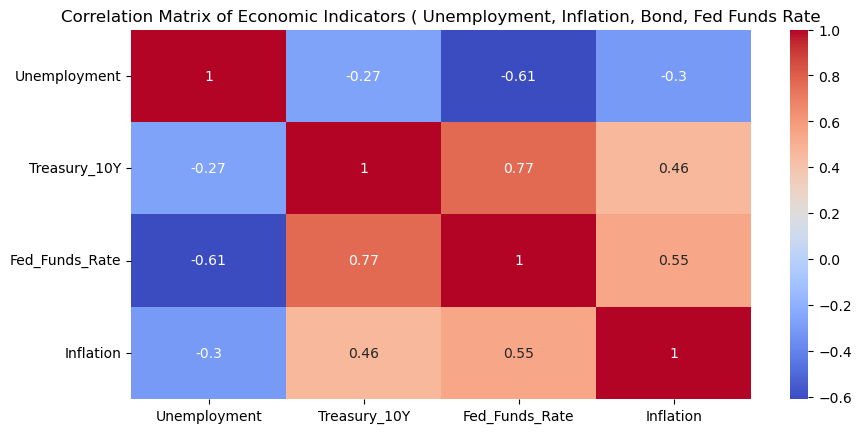

In [14]:
fig, ax = plt.subplots(figsize = (10,4.8))

#creae the heatmaps using seaborn
sns.heatmap(matrix, annot = True, cmap = 'coolwarm', ax=ax)

#to set our title
ax.set_title('Correlation Matrix of Economic Indicators ( Unemployment, Inflation, Bond, Fed Funds Rate')
plt.show()
